In [1]:
import dataset # local import
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

seed = 123
df = dataset.read_agg(month_start=1, month_end=12)
print(df.info())
print(df.head(3))

reading data for month 1
reading data for month 2
reading data for month 3
reading data for month 4
reading data for month 5
reading data for month 6
reading data for month 7
reading data for month 8
reading data for month 9
reading data for month 10
reading data for month 11
reading data for month 12
collecting weather data


/home/kv/education/ml/groupwork/models/ride_demand/dataset.py:297: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  wthr.replace('T', 0, inplace=True)
/home/kv/education/ml/groupwork/models/ride_demand/dataset.py:298: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  wthr.replace('M', np.nan, inplace=True)


collecting calendar data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5128903 entries, 0 to 5128902
Data columns (total 22 columns):
 #   Column            Dtype         
---  ------            -----         
 0   pickup_month      int32         
 1   pickup_week       UInt32        
 2   pickup_date       datetime64[ns]
 3   pickup_dow        int32         
 4   time_of_day       object        
 5   pickup_zone       object        
 6   dropoff_zone      object        
 7   route             object        
 8   total_ride_count  int64         
 9   avg_fare_amount   float64       
 10  temp_high         int64         
 11  precip            float64       
 12  snow              float64       
 13  max_wind_speed    float64       
 14  cloud_coverage    float64       
 15  fog               bool          
 16  low_vis           bool          
 17  thunder           bool          
 18  hail              bool          
 19  freezing_rain     bool          
 20  haze              boo

In [2]:
import pandas as pd

# No need for categorical ordering or complex sorting
daily = df.groupby(['pickup_date', 'time_of_day', 'route'], as_index=False)['total_ride_count'].sum()

# Sort by date to ensure proper shift across days
daily = daily.sort_values(['route', 'time_of_day', 'pickup_date'])

# Lag: same time_of_day, previous day
daily['lag_demand'] = daily.groupby(['route', 'time_of_day'])['total_ride_count'].shift(1)

# Check result
daily[daily['route'] == "Upper East Side North to Upper East Side South"]
df = df.merge(
    daily[['route', 'pickup_date', 'time_of_day', 'lag_demand']],
    on=['time_of_day', 'route', 'pickup_date'],
    how='left'
)
df['lag_demand'] = df['lag_demand'].fillna(0)

In [3]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# Recast object types -> category (just to be sure)
df = df.astype({
    'pickup_zone': 'category',
    'route': 'category',
    'time_of_day': 'category',
    'hail': 'bool',  
    'freezing_rain': 'bool',  
    'holiday': 'category',
})

# Remove waste columns
df['precip'] = df['total_ride_count'] * df['precip']
df['temp_high'] = df['total_ride_count'] * df['temp_high']
df = df.drop(errors='ignore', columns=[
    # 'lag_demand',
    'dropoff_zone',
    'pickup_date',
    'service_route',
    'pickup_service_zone',
    'dropoff_service_zone',
    'pickup_week',
    'pickup_day',  
    'avg_fare_amount',        
    # 'hail',
    # 'freezing_rain',
    # 'haze',

])
# df = df[df['total_ride_count'] >= 40]

# These columns only have a few categories
#
# => onehot encoding is okay
columns_to_onehot_encode = [
    'pickup_dow',
    'time_of_day',
]

# These columns have LOADS of categories
#
# => ordinal encoding is needed             <---- not doing this gives 500GB encoded dataset
#``
# (tried TargetEncoder, but still ended up at 22GB - sticking to ordinal)
columns_to_ordinal_encode = [
    'pickup_zone',
    'route',
    'holiday',
]



# Split `y` BEFORE pipeline
# scaler = StandardScaler()
# y = scaler.fit_transform(df['total_ride_count'].values.reshape(-1, 1))
y = df['total_ride_count']
X = df.drop(columns=['total_ride_count'])

# scaler_lag = StandardScaler()
# X['lag_demand'] = scaler_lag.fit_transform(X['lag_demand'])

# Pipeline
#
# Transfroms the categorical columns to onehot-encoded types
pipeline = ColumnTransformer(
    transformers=[
        #                               +--- `sparse_output=True` stops the encoder duplicating data
        #                               |
        ("onehot", OneHotEncoder(sparse_output=True), columns_to_onehot_encode), 
        ("ordinal", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), columns_to_ordinal_encode),
    ],
    remainder='passthrough'
)
# pipeline.set_output(transform='pandas') # returning pandas cost too much memory
X_encoded = pipeline.fit_transform(X)

# Train vs Test
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=seed)

# Train vs Validation
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.3, random_state=seed)

In [4]:
from sklearn.neural_network import MLPRegressor

nn = MLPRegressor(
    random_state=seed, 
    activation='relu',
    max_iter=2000,
    tol=0.1
)
nn.fit(X_train, y_train)

,loss,'squared_error'
,hidden_layer_sizes,"(100,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,2000
,shuffle,True


Mean Absolute Error: 	1.1169
Mean Squared Error: 	5.5196
R squared: 		0.9669


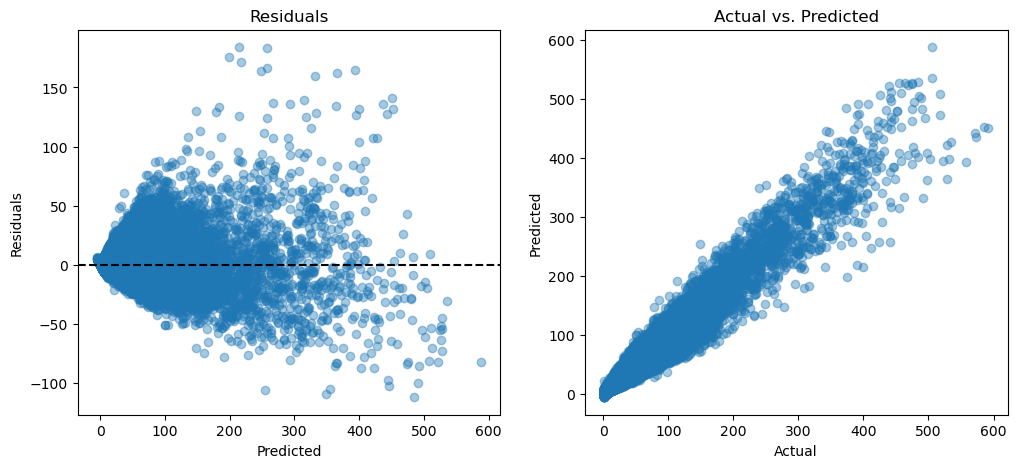

In [5]:
import helpers

training_predictions = nn.predict(X_train)
helpers.analysis(y_train, training_predictions)

Mean Absolute Error: 	1.1185
Mean Squared Error: 	5.5557
R squared: 		0.9663


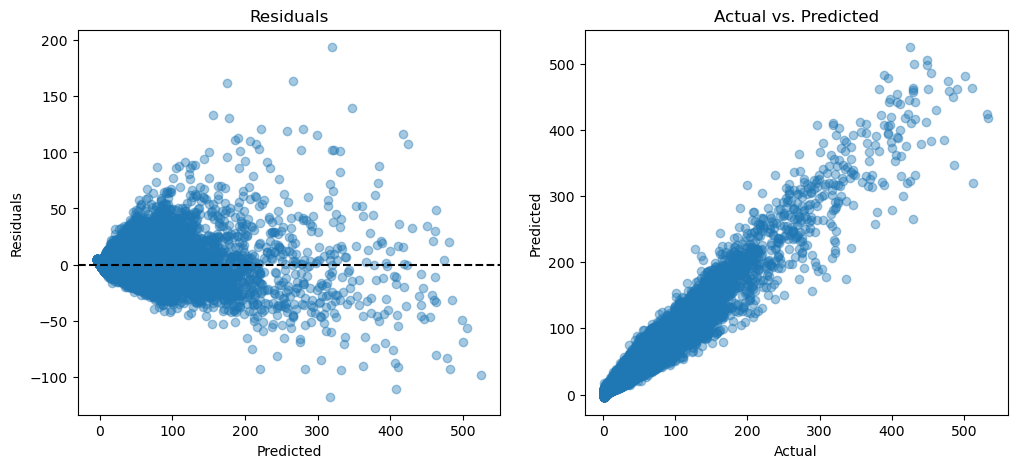

In [6]:
validation_predictions = nn.predict(X_val)
helpers.analysis(y_val, validation_predictions)